In [1]:
# ============================================================
# INDIAN LEGAL CAUSAL TRANSFORMER
# Improved Training Version
#
# Goal:
#   Minimize validation perplexity on the Indian legal corpus.
#
# Dataset:
#   indian-legal-slm-tokenized-2048
#
# Model:
#   Decoder-style causal Transformer
#   512 hidden size
#   8 attention heads
#   6 layers
#   2048 context
#   16,000 vocabulary
#
# IMPORTANT:
#   This version trains FROM SCRATCH.
# ============================================================


In [2]:
!pip install -q -U datasets tokenizers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 56.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires tokenizers<=0.23.0,>=0.22.0, but you have tokenizers 0.23.2 which is incompatible.


In [3]:
import os
import math
import json
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from datasets import load_from_disk
from tokenizers import Tokenizer

In [4]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", DEVICE)

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB
Using: cuda


In [5]:
SEED = 61

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

In [6]:
# Paths

BASE_PATH = (
    "/kaggle/input/datasets/"
    "belovedorange/indian-legal-slm-tokenized-2048"
)

DATASET_PATH = os.path.join(
    BASE_PATH,
    "indian_legal_2048"
)

TOKENIZER_PATH = os.path.join(
    BASE_PATH,
    "indian_legal_tokenizer",
    "tokenizer.json"
)

print("Dataset path:")
print(DATASET_PATH)

print("\nTokenizer path:")
print(TOKENIZER_PATH)


Dataset path:
/kaggle/input/datasets/belovedorange/indian-legal-slm-tokenized-2048/indian_legal_2048

Tokenizer path:
/kaggle/input/datasets/belovedorange/indian-legal-slm-tokenized-2048/indian_legal_tokenizer/tokenizer.json


In [7]:
dataset = load_from_disk(DATASET_PATH)

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['input_ids'],
        num_rows: 155060
    })
    validation: Dataset({
        features: ['input_ids'],
        num_rows: 17474
    })
})


In [8]:
tokenizer = Tokenizer.from_file(
    TOKENIZER_PATH
)

VOCAB_SIZE = tokenizer.get_vocab_size()

PAD_ID = tokenizer.token_to_id("<pad>")
BOS_ID = tokenizer.token_to_id("<bos>")
EOS_ID = tokenizer.token_to_id("<eos>")

print("Vocabulary size:", VOCAB_SIZE)
print("PAD:", PAD_ID)
print("BOS:", BOS_ID)
print("EOS:", EOS_ID)

Vocabulary size: 16000
PAD: 0
BOS: 2
EOS: 3


In [9]:
example = dataset["train"][0]["input_ids"]

print("\nExample sequence length:", len(example))
print("First 20 IDs:", example[:20])

print("\nDecoded example:")
print(tokenizer.decode(example[:500]))


Example sequence length: 2048
First 20 IDs: [2, 5022, 5554, 1102, 5889, 1398, 9, 2556, 100, 606, 83, 4379, 9, 5784, 241, 77, 499, 110, 83, 77]

Decoded example:
ĠCIVIL ĠAPPELLATE ĠCivil ĠAppeals ĠNos . 196 Ġto Ġ201 Ġof Ġ1953 . Appeals Ġfrom Ġthe Ġjudgment Ġand Ġof Ġthe ĠPunjab ĠHigh ĠCourt Ġdated Ġ30 , Ġ1949 , Ġin ĠCivil ĠRegular ĠAppeals ĠNos . 15 67 , Ġ15 68 , Ġ15 69 , Ġ15 70 , Ġ15 73 Ġan Ġ15 74 Ġof Ġ1942 Ġarising Ġout Ġof Ġthe Ġdated ĠJuly Ġ31 , Ġ1942 , Ġof Ġthe ĠCourt Ġof Ġthe ĠDistrict ĠJudge , ĠHoshiarpur Ġin ĠAppeals ĠNos . 104 / 35 Ġof Ġ1941 - Ġ42 , 101 / 32 Ġof Ġ1941 , Ġ103 / 34 Ġ- of Ġ1941 / 42 ) Ġ15 / 73 Ġof Ġ1941 , Ġ102 / 33 Ġof Ġ1941 / 42 Ġand Ġ120 Ġof Ġ1941 Ġarising Ġout Ġof Ġthe Ġdated ĠJuly Ġ24 , Ġ1941 , Ġof Ġthe ĠCourt Ġof ĠSubordinate ĠJudge , Ġ4 th ĠClass , ĠK ang ra Ġin ĠSu its ĠNos . 54 4 , Ġ5 48 , Ġ5 45 , Ġ5 47 , Ġ5 46 Ġand Ġ5 49 Ġof Ġ1940 . B ang ĠBe har ilal Ġand ĠK . ĠR . ĠChaudh ury , Ġfor Ġthe Ġappellant . G an pat ĠRai , Ġfor Ġthe Ġrespondent . M . ĠSik ri 

In [10]:
CONTEXT_LENGTH = 2048

D_MODEL = 512
NUM_HEADS = 8
D_FF = 2048
NUM_LAYERS = 6

DROPOUT = 0.1

print("\nModel configuration:")
print("Context length:", CONTEXT_LENGTH)
print("d_model:", D_MODEL)
print("Heads:", NUM_HEADS)
print("Head dimension:", D_MODEL // NUM_HEADS)
print("Feed-forward dimension:", D_FF)
print("Layers:", NUM_LAYERS)
print("Dropout:", DROPOUT)


Model configuration:
Context length: 2048
d_model: 512
Heads: 8
Head dimension: 64
Feed-forward dimension: 2048
Layers: 6
Dropout: 0.1


In [11]:
BATCH_SIZE = 1

GRAD_ACCUMULATION_STEPS = 16

EPOCHS = 3

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01

# Shorter warmup.
WARMUP_RATIO = 0.03

# Gradient clipping.
MAX_GRAD_NORM = 1.0

# Log every N optimizer steps.
LOG_EVERY = 100

# Save a normal checkpoint every N optimizer steps.
CHECKPOINT_EVERY = 2000

print("\nTraining configuration:")
print("Batch size:", BATCH_SIZE)
print("Gradient accumulation:", GRAD_ACCUMULATION_STEPS)
print(
    "Effective batch size:",
    BATCH_SIZE * GRAD_ACCUMULATION_STEPS
)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Warmup ratio:", WARMUP_RATIO)


Training configuration:
Batch size: 1
Gradient accumulation: 16
Effective batch size: 16
Epochs: 3
Learning rate: 0.0001
Weight decay: 0.01
Warmup ratio: 0.03


In [12]:
class LegalDataset(Dataset):

    def __init__(self, hf_dataset):
        self.dataset = hf_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]["input_ids"]


train_dataset = LegalDataset(
    dataset["train"]
)

val_dataset = LegalDataset(
    dataset["validation"]
)

# train_dataset = LegalDataset(
#     dataset["train"].select(range(10))
# )

# val_dataset = LegalDataset(
#     dataset["validation"].select(range(10))
# )

print("\nTrain sequences:", len(train_dataset))
print("Validation sequences:", len(val_dataset))



Train sequences: 155060
Validation sequences: 17474


In [13]:
def collate_fn(batch):

    max_length = max(
        len(sequence)
        for sequence in batch
    )

    input_ids = torch.full(
        (len(batch), max_length),
        PAD_ID,
        dtype=torch.long
    )

    for i, sequence in enumerate(batch):

        input_ids[
            i,
            :len(sequence)
        ] = torch.tensor(
            sequence,
            dtype=torch.long
        )

    return input_ids

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

print("\nTrain batches:", len(train_loader))
print("Validation batches:", len(val_loader))


Train batches: 155060
Validation batches: 17474


In [15]:


class PositionalEncoding(nn.Module):

    def __init__(
        self,
        d_model,
        max_len
    ):

        super().__init__()

        position = torch.arange(
            max_len,
            dtype=torch.float32
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(
                0,
                d_model,
                2,
                dtype=torch.float32
            )
            *
            (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(
            max_len,
            d_model,
            dtype=torch.float32
        )

        pe[:, 0::2] = torch.sin(
            position * div_term
        )

        pe[:, 1::2] = torch.cos(
            position * div_term
        )

        pe = pe.unsqueeze(0)

        self.register_buffer(
            "pe",
            pe
        )

    def forward(self, x):

        return (
            x
            +
            self.pe[:, :x.size(1)]
        )


In [16]:

class TransformerLanguageModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model,
        num_heads,
        d_ff,
        num_layers,
        max_len,
        dropout
    ):

        super().__init__()

        self.d_model = d_model

        # ----------------------------------------------------
        # Token embedding
        # ----------------------------------------------------

        self.embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=PAD_ID
        )

        # ----------------------------------------------------
        # Positional encoding
        # ----------------------------------------------------

        self.position = PositionalEncoding(
            d_model,
            max_len
        )

        # ----------------------------------------------------
        # Transformer block
        #
        # IMPORTANT IMPROVEMENTS:
        #
        # norm_first=True
        #   -> Pre-LayerNorm
        #
        # activation="gelu"
        #   -> better suited to language modeling
        # ----------------------------------------------------

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # ----------------------------------------------------
        # Final normalization
        # ----------------------------------------------------

        self.norm = nn.LayerNorm(
            d_model
        )

        # ----------------------------------------------------
        # Language-model head
        # ----------------------------------------------------

        self.lm_head = nn.Linear(
            d_model,
            vocab_size,
            bias=False
        )

        # ----------------------------------------------------
        # Weight tying
        #
        # Input embedding and output projection share weights.
        # ----------------------------------------------------

        self.lm_head.weight = self.embedding.weight

        # ----------------------------------------------------
        # Initialize parameters
        # ----------------------------------------------------

        self._init_weights()

    def _init_weights(self):

        # Embedding initialization
        nn.init.normal_(
            self.embedding.weight,
            mean=0.0,
            std=0.02
        )

        # Reinitialize padding embedding to zero.
        if PAD_ID is not None:
            with torch.no_grad():
                self.embedding.weight[PAD_ID].zero_()

        # Linear layers
        for module in self.modules():

            if isinstance(
                module,
                nn.Linear
            ):

                if module is not self.lm_head:

                    nn.init.normal_(
                        module.weight,
                        mean=0.0,
                        std=0.02
                    )

                    if module.bias is not None:
                        nn.init.zeros_(
                            module.bias
                        )

            elif isinstance(
                module,
                nn.LayerNorm
            ):

                nn.init.ones_(
                    module.weight
                )

                nn.init.zeros_(
                    module.bias
                )

    def forward(
        self,
        input_ids,
        padding_mask=None
    ):

        # ----------------------------------------------------
        # Token embeddings
        # ----------------------------------------------------

        x = self.embedding(
            input_ids
        )

        # Same scaling used in the original Transformer.
        x = x * math.sqrt(
            self.d_model
        )

        # ----------------------------------------------------
        # Add positional encoding
        # ----------------------------------------------------

        x = self.position(x)

        # ----------------------------------------------------
        # Causal mask
        #
        # True means the position is MASKED.
        #
        # Example:
        #
        # token 1 cannot see token 2
        # token 2 cannot see token 3
        # etc.
        # ----------------------------------------------------

        seq_len = input_ids.size(1)

        causal_mask = torch.triu(
            torch.ones(
                seq_len,
                seq_len,
                device=input_ids.device,
                dtype=torch.bool
            ),
            diagonal=1
        )

        # ----------------------------------------------------
        # Transformer
        # ----------------------------------------------------

        x = self.transformer(
            x,
            mask=causal_mask,
            src_key_padding_mask=padding_mask
        )

        # ----------------------------------------------------
        # Final normalization
        # ----------------------------------------------------

        x = self.norm(x)

        # ----------------------------------------------------
        # Vocabulary logits
        # ----------------------------------------------------

        logits = self.lm_head(x)

        return logits


In [17]:
model = TransformerLanguageModel(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    num_layers=NUM_LAYERS,
    max_len=CONTEXT_LENGTH,
    dropout=DROPOUT
)

model = model.to(DEVICE)

/tmp/ipykernel_23/987312680.py:59: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [18]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nModel parameters:")
print(
    f"Total parameters: {total_params:,}"
)

print(
    f"Trainable parameters: {trainable_params:,}"
)



Model parameters:
Total parameters: 27,107,328
Trainable parameters: 27,107,328


In [19]:
batch = next(
    iter(train_loader)
)

batch = batch.to(
    DEVICE,
    non_blocking=True
)

print("\nSanity check input:")
print("Shape:", batch.shape)

padding_mask = (
    batch == PAD_ID
)

with torch.no_grad():

    logits = model(
        batch,
        padding_mask
    )

print("Sanity check output:")
print("Shape:", logits.shape)

assert logits.shape[0] == batch.shape[0]
assert logits.shape[1] == batch.shape[1]
assert logits.shape[2] == VOCAB_SIZE

print("Sanity check PASSED.")



Sanity check input:
Shape: torch.Size([1, 1900])
Sanity check output:
Shape: torch.Size([1, 1900, 16000])
Sanity check PASSED.


In [20]:
test_length = 8

test_mask = torch.triu(
    torch.ones(
        test_length,
        test_length
    ),
    diagonal=1
).bool()

print("\nCausal attention visibility:")

print(
    (~test_mask).int()
)

print(
    "\nThe model can attend to the current token "
    "and all previous tokens, but never future tokens."
)



Causal attention visibility:
tensor([[1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1]], dtype=torch.int32)

The model can attend to the current token and all previous tokens, but never future tokens.


In [21]:
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID
)

In [22]:
try:

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        betas=(0.9, 0.95),
        eps=1e-8,
        fused=(DEVICE.type == "cuda")
    )

    print("\nUsing AdamW with fused CUDA implementation.")

except Exception:

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        betas=(0.9, 0.95),
        eps=1e-8
    )

    print("\nUsing standard AdamW.")



Using AdamW with fused CUDA implementation.


In [23]:
steps_per_epoch = math.ceil(
    len(train_loader)
    /
    GRAD_ACCUMULATION_STEPS
)

TOTAL_STEPS = (
    steps_per_epoch
    *
    EPOCHS
)

WARMUP_STEPS = max(
    1,
    int(
        TOTAL_STEPS
        *
        WARMUP_RATIO
    )
)

print("\nTraining steps:")
print("Steps per epoch:", steps_per_epoch)
print("Total optimizer steps:", TOTAL_STEPS)
print("Warmup steps:", WARMUP_STEPS)


Training steps:
Steps per epoch: 9692
Total optimizer steps: 29076
Warmup steps: 872


In [24]:
def get_lr_multiplier(
    current_step
):

    # --------------------------------------------------------
    # Warmup
    # --------------------------------------------------------

    if current_step < WARMUP_STEPS:

        return (
            float(current_step + 1)
            /
            float(WARMUP_STEPS)
        )

    # --------------------------------------------------------
    # Cosine decay
    # --------------------------------------------------------

    progress = (
        current_step
        -
        WARMUP_STEPS
    ) / max(
        1,
        TOTAL_STEPS
        -
        WARMUP_STEPS
    )

    progress = min(
        1.0,
        max(
            0.0,
            progress
        )
    )

    return (
        0.5
        *
        (
            1.0
            +
            math.cos(
                math.pi
                *
                progress
            )
        )
    )


scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=get_lr_multiplier
)


In [25]:
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(DEVICE.type == "cuda")
)


In [26]:
MODEL_DIR = (
    "/kaggle/working/"
    "indian_legal_transformer_improved"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_model.pt"
)

FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "transformer_model.pt"
)

CHECKPOINT_PATH = os.path.join(
    MODEL_DIR,
    "latest_checkpoint.pt"
)

CONFIG_PATH = os.path.join(
    MODEL_DIR,
    "config.json"
)

In [27]:
def train_one_epoch(
    epoch
):

    model.train()

    optimizer.zero_grad(
        set_to_none=True
    )

    epoch_loss_sum = 0.0
    epoch_batches = 0

    # --------------------------------------------------------
    # Track recent losses separately.
    #
    # This is important because the beginning of training can
    # have very large losses due to warmup.
    # --------------------------------------------------------

    recent_losses = []

    optimizer_steps_this_epoch = 0

    start_time = time.time()

    for step, batch in enumerate(
        train_loader
    ):

        batch = batch.to(
            DEVICE,
            non_blocking=True
        )

        # ----------------------------------------------------
        # Shift input and labels
        #
        # Input:
        #   A B C D
        #
        # Labels:
        #   B C D E
        #
        # The model predicts the next token.
        # ----------------------------------------------------

        inputs = batch[:, :-1]

        labels = batch[:, 1:]

        padding_mask = (
            inputs == PAD_ID
        )

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=(DEVICE.type == "cuda")
        ):

            logits = model(
                inputs,
                padding_mask
            )

            loss = criterion(
                logits.reshape(
                    -1,
                    VOCAB_SIZE
                ),
                labels.reshape(
                    -1
                )
            )

        # ----------------------------------------------------
        # Save ORIGINAL loss before dividing it.
        # ----------------------------------------------------

        loss_value = loss.detach().item()

        epoch_loss_sum += loss_value
        epoch_batches += 1

        recent_losses.append(
            loss_value
        )

        if len(recent_losses) > 1000:
            recent_losses.pop(0)

        # ----------------------------------------------------
        # Gradient accumulation
        # ----------------------------------------------------

        loss_for_backward = (
            loss
            /
            GRAD_ACCUMULATION_STEPS
        )

        scaler.scale(
            loss_for_backward
        ).backward()

        # ----------------------------------------------------
        # Optimizer step
        # ----------------------------------------------------

        should_step = (
            (step + 1)
            %
            GRAD_ACCUMULATION_STEPS
            == 0
        )

        is_last_batch = (
            (step + 1)
            ==
            len(train_loader)
        )

        if should_step or is_last_batch:

            # Unscale before gradient clipping.
            scaler.unscale_(
                optimizer
            )

            grad_norm = (
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    MAX_GRAD_NORM
                )
            )

            scaler.step(
                optimizer
            )

            scaler.update()

            scheduler.step()

            optimizer.zero_grad(
                set_to_none=True
            )

            optimizer_steps_this_epoch += 1

            # ------------------------------------------------
            # Current learning rate
            # ------------------------------------------------

            current_lr = (
                optimizer.param_groups[0]["lr"]
            )

            # ------------------------------------------------
            # Logging
            # ------------------------------------------------

            global_optimizer_step = (
                epoch
                *
                steps_per_epoch
                +
                optimizer_steps_this_epoch
            )

            if (
                optimizer_steps_this_epoch
                %
                LOG_EVERY
                == 0
            ):

                recent_mean = (
                    sum(recent_losses)
                    /
                    len(recent_losses)
                )

                elapsed = (
                    time.time()
                    -
                    start_time
                )

                print(
                    f"Epoch {epoch + 1}/{EPOCHS} | "
                    f"Opt Step {global_optimizer_step:,}/{TOTAL_STEPS:,} | "
                    f"Batch {step + 1:,}/{len(train_loader):,} | "
                    f"Loss: {loss_value:.4f} | "
                    f"Recent Loss: {recent_mean:.4f} | "
                    f"LR: {current_lr:.3e} | "
                    f"Grad Norm: {float(grad_norm):.3f} | "
                    f"Time: {elapsed / 60:.1f} min"
                )

            # ------------------------------------------------
            # Periodic checkpoint
            # ------------------------------------------------

            if (
                global_optimizer_step
                %
                CHECKPOINT_EVERY
                == 0
            ):

                torch.save(
                    {
                        "epoch": epoch,
                        "batch_step": step,
                        "optimizer_step":
                            global_optimizer_step,
                        "model_state_dict":
                            model.state_dict(),
                        "optimizer_state_dict":
                            optimizer.state_dict(),
                        "scheduler_state_dict":
                            scheduler.state_dict(),
                        "scaler_state_dict":
                            scaler.state_dict(),
                        "train_loss":
                            loss_value
                    },
                    CHECKPOINT_PATH
                )

                print(
                    f"\nCheckpoint saved at "
                    f"optimizer step "
                    f"{global_optimizer_step:,}\n"
                )

    # --------------------------------------------------------
    # Proper epoch mean.
    # --------------------------------------------------------

    epoch_loss = (
        epoch_loss_sum
        /
        epoch_batches
    )

    # --------------------------------------------------------
    # Recent loss is much more informative about convergence
    # than the lifetime average.
    # --------------------------------------------------------

    recent_loss = (
        sum(recent_losses)
        /
        len(recent_losses)
    )

    return (
        epoch_loss,
        recent_loss
    )


In [28]:

@torch.no_grad()
def evaluate():

    model.eval()

    total_loss = 0.0
    total_batches = 0

    for batch in val_loader:

        batch = batch.to(
            DEVICE,
            non_blocking=True
        )

        inputs = batch[:, :-1]

        labels = batch[:, 1:]

        padding_mask = (
            inputs == PAD_ID
        )

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=(DEVICE.type == "cuda")
        ):

            logits = model(
                inputs,
                padding_mask
            )

            loss = criterion(
                logits.reshape(
                    -1,
                    VOCAB_SIZE
                ),
                labels.reshape(
                    -1
                )
            )

        total_loss += loss.item()
        total_batches += 1

    return (
        total_loss
        /
        total_batches
    )


In [29]:
def calculate_perplexity(
    loss
):

    # Prevent overflow.
    return math.exp(
        min(
            loss,
            20
        )
    )


In [30]:
train_losses = []
recent_train_losses = []
val_losses = []

train_ppls = []
val_ppls = []

learning_rates = []

best_val_loss = float("inf")

best_epoch = -1

In [31]:
print("\n")
print("=" * 70)
print("STARTING TRANSFORMER TRAINING")
print("=" * 70)

training_start = time.time()


for epoch in range(EPOCHS):

    print("\n")
    print("=" * 70)

    print(
        f"Epoch {epoch + 1}/{EPOCHS}"
    )

    print("=" * 70)

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_loss, recent_loss = (
        train_one_epoch(
            epoch
        )
    )

    # --------------------------------------------------------
    # VALIDATE
    # --------------------------------------------------------

    print("\nRunning validation...")

    val_loss = evaluate()

    # --------------------------------------------------------
    # Perplexities
    # --------------------------------------------------------

    train_ppl = calculate_perplexity(
        train_loss
    )

    recent_train_ppl = calculate_perplexity(
        recent_loss
    )

    val_ppl = calculate_perplexity(
        val_loss
    )

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    train_losses.append(
        train_loss
    )

    recent_train_losses.append(
        recent_loss
    )

    val_losses.append(
        val_loss
    )

    train_ppls.append(
        train_ppl
    )

    val_ppls.append(
        val_ppl
    )

    learning_rates.append(
        current_lr
    )

    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------

    print("\n")
    print("-" * 70)

    print(
        f"Epoch {epoch + 1} RESULTS"
    )

    print("-" * 70)

    print(
        f"Train loss:          {train_loss:.4f}"
    )

    print(
        f"Recent train loss:   {recent_loss:.4f}"
    )

    print(
        f"Validation loss:     {val_loss:.4f}"
    )

    print(
        f"Train perplexity:    {train_ppl:.2f}"
    )

    print(
        f"Recent train PPL:    {recent_train_ppl:.2f}"
    )

    print(
        f"Validation PPL:      {val_ppl:.2f}"
    )

    print(
        f"Learning rate:       {current_lr:.3e}"
    )

    # --------------------------------------------------------
    # Best model based ONLY on validation loss
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_epoch = epoch

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            "\n*** NEW BEST MODEL SAVED ***"
        )

        print(
            f"Best validation loss: "
            f"{best_val_loss:.4f}"
        )

        print(
            f"Best validation PPL: "
            f"{calculate_perplexity(best_val_loss):.2f}"
        )

    else:

        print(
            "\nValidation loss did not improve."
        )

    print("-" * 70)


training_time = (
    time.time()
    -
    training_start
)

print("\n")
print("=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(
    f"Total training time: "
    f"{training_time / 3600:.2f} hours"
)

print(
    f"Best epoch: "
    f"{best_epoch + 1}"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

print(
    f"Best validation perplexity: "
    f"{calculate_perplexity(best_val_loss):.2f}"
)



STARTING TRANSFORMER TRAINING


Epoch 1/3
Epoch 1/3 | Opt Step 100/29,076 | Batch 1,600/155,060 | Loss: 8.6169 | Recent Loss: 8.9224 | LR: 1.158e-05 | Grad Norm: 1.967 | Time: 1.9 min
Epoch 1/3 | Opt Step 200/29,076 | Batch 3,200/155,060 | Loss: 7.4128 | Recent Loss: 7.8651 | LR: 2.305e-05 | Grad Norm: 1.832 | Time: 3.9 min
Epoch 1/3 | Opt Step 300/29,076 | Batch 4,800/155,060 | Loss: 6.4838 | Recent Loss: 6.8082 | LR: 3.452e-05 | Grad Norm: 0.950 | Time: 6.0 min
Epoch 1/3 | Opt Step 400/29,076 | Batch 6,400/155,060 | Loss: 5.7940 | Recent Loss: 6.1409 | LR: 4.599e-05 | Grad Norm: 0.474 | Time: 8.1 min
Epoch 1/3 | Opt Step 500/29,076 | Batch 8,000/155,060 | Loss: 5.8182 | Recent Loss: 5.7814 | LR: 5.745e-05 | Grad Norm: 0.405 | Time: 10.1 min
Epoch 1/3 | Opt Step 600/29,076 | Batch 9,600/155,060 | Loss: 5.6056 | Recent Loss: 5.5360 | LR: 6.892e-05 | Grad Norm: 0.487 | Time: 12.2 min
Epoch 1/3 | Opt Step 700/29,076 | Batch 11,200/155,060 | Loss: 5.3085 | Recent Loss: 5.3790 | LR: 8.03

In [32]:
print("\nLoading best validation model...")

best_state_dict = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(
    best_state_dict
)

model.eval()

print("Best model loaded.")


Loading best validation model...
Best model loaded.


In [33]:
print("\nRunning final validation on best model...")

final_val_loss = evaluate()

final_val_ppl = calculate_perplexity(
    final_val_loss
)

print("\n")
print("=" * 70)
print("FINAL BEST MODEL METRICS")
print("=" * 70)

print(
    f"Validation loss:       {final_val_loss:.4f}"
)

print(
    f"Validation perplexity: {final_val_ppl:.2f}"
)

print("=" * 70)


Running final validation on best model...


FINAL BEST MODEL METRICS
Validation loss:       2.8619
Validation perplexity: 17.50


In [34]:
torch.save(
    model.state_dict(),
    FINAL_MODEL_PATH
)

print(
    "\nFinal model saved to:"
)

print(
    FINAL_MODEL_PATH
)


Final model saved to:
/kaggle/working/indian_legal_transformer_improved/transformer_model.pt


In [35]:
config = {

    "architecture":
        "Causal Transformer Language Model",

    "vocab_size":
        VOCAB_SIZE,

    "context_length":
        CONTEXT_LENGTH,

    "d_model":
        D_MODEL,

    "num_heads":
        NUM_HEADS,

    "head_dimension":
        D_MODEL // NUM_HEADS,

    "d_ff":
        D_FF,

    "num_layers":
        NUM_LAYERS,

    "dropout":
        DROPOUT,

    "activation":
        "gelu",

    "norm_first":
        True,

    "weight_tying":
        True,

    "batch_size":
        BATCH_SIZE,

    "gradient_accumulation_steps":
        GRAD_ACCUMULATION_STEPS,

    "effective_batch_size":
        BATCH_SIZE *
        GRAD_ACCUMULATION_STEPS,

    "epochs":
        EPOCHS,

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "warmup_ratio":
        WARMUP_RATIO,

    "max_grad_norm":
        MAX_GRAD_NORM,

    "seed":
        SEED,

    "best_epoch":
        best_epoch + 1,

    "best_validation_loss":
        final_val_loss,

    "best_validation_perplexity":
        final_val_ppl
}


with open(
    CONFIG_PATH,
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print(
    "Configuration saved to:"
)

print(
    CONFIG_PATH
)



Configuration saved to:
/kaggle/working/indian_legal_transformer_improved/config.json


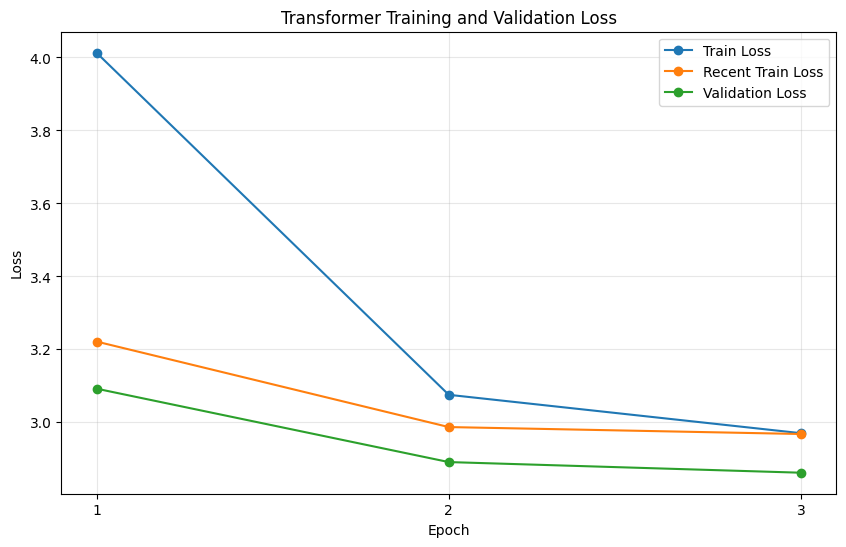

In [36]:
epochs_axis = np.arange(
    1,
    EPOCHS + 1
)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_axis,
    train_losses,
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs_axis,
    recent_train_losses,
    marker="o",
    label="Recent Train Loss"
)

plt.plot(
    epochs_axis,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Transformer Training and Validation Loss"
)

plt.xticks(
    epochs_axis
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.show()

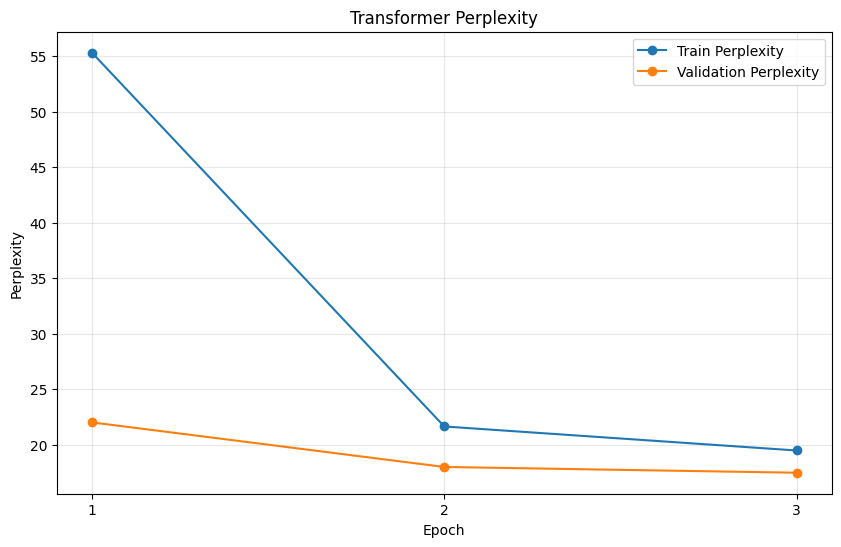

In [37]:

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_axis,
    train_ppls,
    marker="o",
    label="Train Perplexity"
)

plt.plot(
    epochs_axis,
    val_ppls,
    marker="o",
    label="Validation Perplexity"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Perplexity"
)

plt.title(
    "Transformer Perplexity"
)

plt.xticks(
    epochs_axis
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.show()

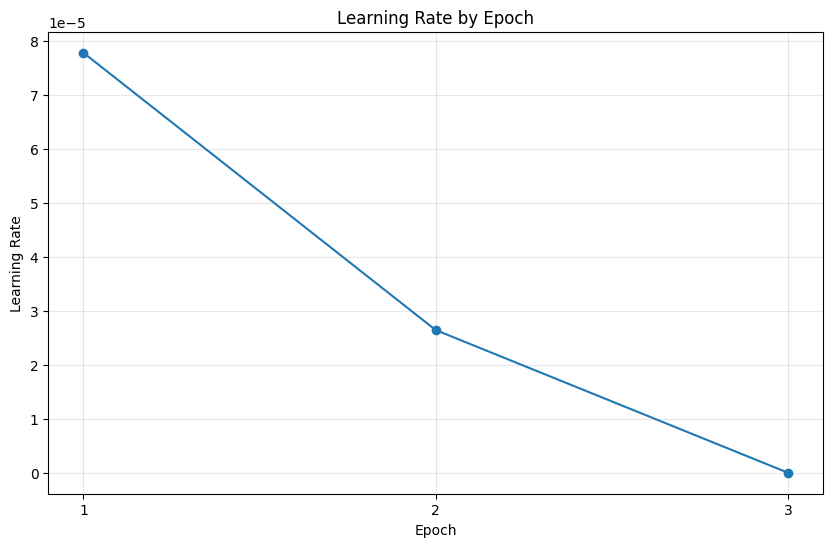

In [38]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_axis,
    learning_rates,
    marker="o"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Learning Rate"
)

plt.title(
    "Learning Rate by Epoch"
)

plt.xticks(
    epochs_axis
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()

In [39]:
@torch.no_grad()
def generate(
    prompt,
    max_new_tokens=150,
    temperature=0.8,
    top_k=50,
    top_p=0.95
):

    model.eval()

    # --------------------------------------------------------
    # Encode prompt
    # --------------------------------------------------------

    prompt_ids = tokenizer.encode(
        prompt
    ).ids

    if len(prompt_ids) == 0:

        raise ValueError(
            "Prompt produced no tokens."
        )

    # --------------------------------------------------------
    # Convert to tensor
    # --------------------------------------------------------

    input_ids = torch.tensor(
        [prompt_ids],
        dtype=torch.long,
        device=DEVICE
    )

    # --------------------------------------------------------
    # Generate token-by-token
    # --------------------------------------------------------

    for _ in range(
        max_new_tokens
    ):

        # Keep only context window.
        input_ids = input_ids[
            :,
            -CONTEXT_LENGTH:
        ]

        padding_mask = (
            input_ids == PAD_ID
        )

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=(DEVICE.type == "cuda")
        ):

            logits = model(
                input_ids,
                padding_mask
            )

        # ----------------------------------------------------
        # Get logits for final token
        # ----------------------------------------------------

        logits = logits[
            :,
            -1,
            :
        ]

        # ----------------------------------------------------
        # Temperature
        # ----------------------------------------------------

        logits = (
            logits
            /
            max(
                temperature,
                1e-5
            )
        )

        # ----------------------------------------------------
        # Top-K filtering
        # ----------------------------------------------------

        if top_k is not None:

            top_k = min(
                top_k,
                logits.size(-1)
            )

            values, _ = torch.topk(
                logits,
                top_k
            )

            minimum_value = (
                values[
                    :,
                    -1
                ].unsqueeze(-1)
            )

            logits = torch.where(
                logits < minimum_value,
                torch.full_like(
                    logits,
                    float("-inf")
                ),
                logits
            )

        # ----------------------------------------------------
        # Top-P / nucleus sampling
        # ----------------------------------------------------

        if top_p is not None:

            sorted_logits, sorted_indices = (
                torch.sort(
                    logits,
                    descending=True
                )
            )

            sorted_probabilities = (
                F.softmax(
                    sorted_logits,
                    dim=-1
                )
            )

            cumulative_probabilities = (
                torch.cumsum(
                    sorted_probabilities,
                    dim=-1
                )
            )

            sorted_indices_to_remove = (
                cumulative_probabilities
                >
                top_p
            )

            # Keep at least one token.
            sorted_indices_to_remove[
                :,
                0
            ] = False

            indices_to_remove = (
                torch.zeros_like(
                    logits,
                    dtype=torch.bool
                )
            )

            indices_to_remove.scatter_(
                1,
                sorted_indices,
                sorted_indices_to_remove
            )

            logits = logits.masked_fill(
                indices_to_remove,
                float("-inf")
            )

        # ----------------------------------------------------
        # Probabilities
        # ----------------------------------------------------

        probabilities = F.softmax(
            logits,
            dim=-1
        )

        # ----------------------------------------------------
        # Sample
        # ----------------------------------------------------

        next_token = torch.multinomial(
            probabilities,
            num_samples=1
        )

        # ----------------------------------------------------
        # Append
        # ----------------------------------------------------

        input_ids = torch.cat(
            [
                input_ids,
                next_token
            ],
            dim=1
        )

        # ----------------------------------------------------
        # Stop at EOS
        # ----------------------------------------------------

        if (
            next_token.item()
            ==
            EOS_ID
        ):

            break

    # --------------------------------------------------------
    # Decode
    # --------------------------------------------------------

    return tokenizer.decode(
        input_ids[0].tolist(),
        skip_special_tokens=True
    ).replace("Ġ", "")



In [40]:

prompts = [

    "What are the fundamental rights guaranteed by the Constitution of India?",

    "What is the role of the Supreme Court of India in interpreting the Constitution?",

    "What are the grounds on which a person can file a writ petition?",

    "What is meant by natural justice in Indian law?",

    "What is the difference between civil and criminal liability?",

    "When can a court grant bail to an accused person?",

    "What are the essential elements required to establish negligence?",

    "What powers does a High Court have under Article 226 of the Constitution?",

    "What is the meaning of Article 21 of the Constitution of India?",

    "What is the principle of res judicata under Indian law?"

]

for prompt in prompts:

    print("\n")
    print("=" * 70)

    print(
        "PROMPT:"
    )

    print(
        prompt
    )

    print("-" * 70)

    generated = generate(
        prompt,
        max_new_tokens=150,
        temperature=0.8,
        top_k=50,
        top_p=0.95
    )

    print(
        generated
    )



PROMPT:
What are the fundamental rights guaranteed by the Constitution of India?
----------------------------------------------------------------------
What are the fundamental rights guaranteed by the Const it ution of India ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ?


PROMPT:
What is the role of the Supreme Court of India in interpreting the Constitution?
----------------------------------------------------------------------
What is the role of the Supreme Court of India in interpreting the Const it ution ? What is the role of the Supreme Court in interpreting the Const it ution ? What is the role of the Supreme Court in interpreting the Const it ution ? What is the role of the Supreme Court in interpreting the Const it ution ?

In [41]:

print("\n")
print("=" * 70)
print("TRANSFORMER TRAINING SUMMARY")
print("=" * 70)

print(
    f"Parameters:              {total_params:,}"
)

print(
    f"Training sequences:      {len(train_dataset):,}"
)

print(
    f"Validation sequences:    {len(val_dataset):,}"
)

print(
    f"Context length:          {CONTEXT_LENGTH}"
)

print(
    f"Vocabulary size:         {VOCAB_SIZE:,}"
)

print(
    f"Epochs:                  {EPOCHS}"
)

print(
    f"Effective batch size:    "
    f"{BATCH_SIZE * GRAD_ACCUMULATION_STEPS}"
)

print(
    f"Learning rate:           {LEARNING_RATE}"
)

print(
    f"Warmup ratio:            {WARMUP_RATIO}"
)

print(
    f"Best epoch:              {best_epoch + 1}"
)

print(
    f"Best validation loss:    {final_val_loss:.4f}"
)

print(
    f"Best validation PPL:     {final_val_ppl:.2f}"
)

print(
    "\nModel directory:"
)

print(
    MODEL_DIR
)

print("=" * 70)



TRANSFORMER TRAINING SUMMARY
Parameters:              27,107,328
Training sequences:      155,060
Validation sequences:    17,474
Context length:          2048
Vocabulary size:         16,000
Epochs:                  3
Effective batch size:    16
Learning rate:           0.0001
Warmup ratio:            0.03
Best epoch:              3
Best validation loss:    2.8619
Best validation PPL:     17.50

Model directory:
/kaggle/working/indian_legal_transformer_improved
